# Occupations — share of active individuals over time (World, Roman Empire, Tang Dynasty) and co-occupation networks for astronomers.

In [1]:
import random
from collections import Counter
from itertools import combinations

import numpy as np
import polars as pl
import duckdb
import networkx as nx
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../../data/humans_clean.duckdb'

COLORS = {
    'astronomer':       '#2171b5',
    'astrologer':       '#f4a0a0',
    'writer':           '#a0d8a0',
    'other_node':       '#d9e2f3',
    'edge':             '#555555',
    'other_occupation': (0.82, 0.82, 0.82),
}

plt.rcParams.update({
    'figure.dpi':       120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    14,
    'axes.labelsize':    13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'legend.fontsize':   11,
})

## Connect

In [2]:
con = duckdb.connect(DB_PATH, read_only=True)

## Constants

In [3]:
WORLD_RANGE = (-500, 2018)

POLITY_NAMES = ['Roman Empire', 'Tang Dynasty']

TOP_OCCUPATIONS_PER_CENTURY = 10
MAX_OCCUPATIONS_PER_SCOPE   = 20
SMOOTH_WINDOW_YEARS         = 11

ASTRONOMER_PERIODS = {
    '750 – 1250':  ( 750, 1250),
    '1400 – 1650': (1400, 1650),
    '1750 – 1950': (1750, 1950),
}

ASTRONOMER_VARIANTS = [
    'amateur astronomer',
    'radio astronomer',
    'archaeoastronomer',
    'astronomer royal',
]

NETWORK_NODE_COUNT     = 15
NETWORK_MIN_EDGE_COUNT = 2

## World cohort

In [4]:
individuals_world = con.execute("""
    SELECT individuals.wikidata_id,
           individuals.occupations_en,
           floruit.floruit_period_start,
           floruit.floruit_period_end
    FROM   individuals
    JOIN   individuals_floruit_period AS floruit USING (wikidata_id)
    WHERE  individuals.occupations_en   IS NOT NULL AND individuals.occupations_en <> ''
      AND  floruit.floruit_period_start IS NOT NULL
      AND  floruit.floruit_period_end   IS NOT NULL
""").pl()

print('shape:', individuals_world.shape)
individuals_world.head()

shape: (7448923, 4)


wikidata_id,occupations_en,floruit_period_start,floruit_period_end
str,str,i64,i64
"""Q108780052""","""archaeologist""",1956,1981
"""Q108780082""","""scholar of Japanese literature""",1947,1972
"""Q108780087""","""writer""",1964,1967
"""Q108780090""","""wheelchair basketball player""",1970,1995
"""Q108780091""","""high school student""",2007,2007


## Exploded occupations

In [5]:
def explode_occupations(individuals):
    return (
        individuals
        .with_columns(pl.col('occupations_en').str.split('; ').alias('occupation_list'))
        .explode('occupation_list')
        .rename({'occupation_list': 'occupation'})
        .with_columns(pl.col('occupation').str.strip_chars())
        .filter(pl.col('occupation').is_not_null() & (pl.col('occupation') != ''))
    )

occupation_rows_world = explode_occupations(individuals_world)

print('shape:', occupation_rows_world.shape)
occupation_rows_world.head()

shape: (10763913, 5)


wikidata_id,occupations_en,floruit_period_start,floruit_period_end,occupation
str,str,i64,i64,str
"""Q108780052""","""archaeologist""",1956,1981,"""archaeologist"""
"""Q108780082""","""scholar of Japanese literature""",1947,1972,"""scholar of Japanese literature"""
"""Q108780087""","""writer""",1964,1967,"""writer"""
"""Q108780090""","""wheelchair basketball player""",1970,1995,"""wheelchair basketball player"""
"""Q108780091""","""high school student""",2007,2007,"""high school student"""


## Polity year spans

In [6]:
polity_year_spans = con.execute("""
    SELECT polity_name,
           MIN(from_year) AS polity_start,
           MAX(to_year)   AS polity_end
    FROM   polities_periods_cliopatria
    WHERE  polity_name IN ('Roman Empire', 'Tang Dynasty')
    GROUP  BY polity_name
""").pl()

print('shape:', polity_year_spans.shape)
polity_year_spans

shape: (2, 3)


polity_name,polity_start,polity_end
str,i64,i64
"""Roman Empire""",-31,394
"""Tang Dynasty""",623,910


In [7]:
def round_to_century_outward(start_year, end_year):
    return (start_year // 100) * 100, ((end_year + 99) // 100) * 100 - 1

polity_to_year_range = {
    row['polity_name']: round_to_century_outward(row['polity_start'], row['polity_end'])
    for row in polity_year_spans.iter_rows(named=True)
}
ROMAN_RANGE = polity_to_year_range['Roman Empire']
TANG_RANGE  = polity_to_year_range['Tang Dynasty']

print('ROMAN_RANGE:', ROMAN_RANGE)
print('TANG_RANGE: ', TANG_RANGE)

ROMAN_RANGE: (-100, 399)
TANG_RANGE:  (600, 999)


## Polity cohorts

In [8]:
def fetch_polity_cohort(polity_name):
    return con.execute("""
        SELECT cliopatria.wikidata_id,
               individuals.occupations_en,
               cliopatria.floruit_period_start,
               cliopatria.floruit_period_end
        FROM   individuals_cliopatria AS cliopatria
        JOIN   individuals USING (wikidata_id)
        WHERE  ';' || cliopatria.polity_name || ';' LIKE '%;' || ? || ';%'
          AND  individuals.occupations_en   IS NOT NULL AND individuals.occupations_en <> ''
          AND  cliopatria.floruit_period_start IS NOT NULL
          AND  cliopatria.floruit_period_end   IS NOT NULL
    """, [polity_name]).pl()

individuals_roman = fetch_polity_cohort('Roman Empire')
print('shape:', individuals_roman.shape)
individuals_roman.head()

shape: (3708, 4)


wikidata_id,occupations_en,floruit_period_start,floruit_period_end
str,str,i32,i32
"""Q12285134""","""politician""",101,200
"""Q12285138""","""politician""",80,105
"""Q12285139""","""politician""",1,100
"""Q12285140""","""politician""",101,200
"""Q12285141""","""politician""",1,100


In [9]:
individuals_tang = fetch_polity_cohort('Tang Dynasty')
print('shape:', individuals_tang.shape)
individuals_tang.head()

shape: (1989, 4)


wikidata_id,occupations_en,floruit_period_start,floruit_period_end
str,str,i32,i32
"""Q1001807""","""military personnel""",801,900
"""Q1005372""","""military leader""",613,638
"""Q10975505""","""painter; politician""",654,679
"""Q10987941""","""politician""",818,837
"""Q11002835""","""writer; poet""",756,781


In [10]:
occupation_rows_roman = explode_occupations(individuals_roman)
occupation_rows_tang  = explode_occupations(individuals_tang)

print('roman shape:', occupation_rows_roman.shape)
print('tang  shape:', occupation_rows_tang.shape)
occupation_rows_roman.head()

roman shape: (5313, 5)
tang  shape: (2577, 5)


wikidata_id,occupations_en,floruit_period_start,floruit_period_end,occupation
str,str,i32,i32,str
"""Q12285134""","""politician""",101,200,"""politician"""
"""Q12285138""","""politician""",80,105,"""politician"""
"""Q12285139""","""politician""",1,100,"""politician"""
"""Q12285140""","""politician""",101,200,"""politician"""
"""Q12285141""","""politician""",1,100,"""politician"""


## Top occupations per scope

In [11]:
def top_occupations_per_century(occupation_rows, year_range, top_per_century, max_total):
    year_lo, year_hi = year_range
    century_counts = (
        occupation_rows
        .filter(pl.col('floruit_period_start').is_between(year_lo, year_hi))
        .with_columns(((pl.col('floruit_period_start') // 100) * 100).alias('century'))
        .group_by('century', 'occupation').len()
        .rename({'len': 'individual_count'})
    )
    ranked_in_century = century_counts.with_columns(
        pl.col('individual_count').rank(method='ordinal', descending=True).over('century').alias('rank_in_century')
    )
    return (
        ranked_in_century
        .filter(pl.col('rank_in_century') <= top_per_century)
        .group_by('occupation')
        .agg(
            pl.col('individual_count').sum().alias('total_individuals'),
            pl.col('rank_in_century').min().alias('best_rank'),
        )
        .sort(['total_individuals', 'best_rank'], descending=[True, False])
        .head(max_total)
    )

world_top = top_occupations_per_century(occupation_rows_world, WORLD_RANGE, TOP_OCCUPATIONS_PER_CENTURY, MAX_OCCUPATIONS_PER_SCOPE)
roman_top = top_occupations_per_century(occupation_rows_roman, ROMAN_RANGE, TOP_OCCUPATIONS_PER_CENTURY, MAX_OCCUPATIONS_PER_SCOPE)
tang_top  = top_occupations_per_century(occupation_rows_tang,  TANG_RANGE,  TOP_OCCUPATIONS_PER_CENTURY, MAX_OCCUPATIONS_PER_SCOPE)

print('world shape:', world_top.shape)
print('roman shape:', roman_top.shape)
print('tang  shape:', tang_top.shape)
world_top.head()

world shape: (20, 3)
roman shape: (18, 3)
tang  shape: (15, 3)


occupation,total_individuals,best_rank
str,u32,u32
"""researcher""",1428424,1
"""politician""",698158,1
"""writer""",348990,2
"""university teacher""",261724,3
"""actor""",209670,4


## Shared occupation palette

In [12]:
world_occupations = world_top['occupation'].to_list()
roman_occupations = roman_top['occupation'].to_list()
tang_occupations  = tang_top['occupation'].to_list()

def build_shared_palette(occupation_lists):
    seen = []
    for lst in occupation_lists:
        for occupation in lst:
            if occupation not in seen:
                seen.append(occupation)
    base_colors = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)
    palette = {occupation: base_colors[i % len(base_colors)] for i, occupation in enumerate(seen)}
    palette['Other'] = COLORS['other_occupation']
    return palette

occupation_palette = build_shared_palette([world_occupations, roman_occupations, tang_occupations])
print(f'shared palette: {len(occupation_palette) - 1} occupations + Other')

shared palette: 39 occupations + Other


## Active-per-year sweep

In [13]:
def active_individuals_per_year(occupation_rows, top_occupation_list, year_range):
    year_lo, year_hi = year_range
    bucketed = (
        occupation_rows
        .with_columns(
            pl.when(pl.col('occupation').is_in(top_occupation_list))
              .then(pl.col('occupation'))
              .otherwise(pl.lit('Other'))
              .alias('occupation_group'),
            pl.col('floruit_period_start').clip(year_lo, year_hi).alias('start_clipped'),
            pl.col('floruit_period_end').clip(year_lo, year_hi).alias('end_clipped'),
        )
        .filter(pl.col('start_clipped') <= pl.col('end_clipped'))
    )
    occupation_order = list(top_occupation_list) + ['Other']
    years = np.arange(year_lo, year_hi + 1)
    counts_by_occupation = {}
    for occupation in occupation_order:
        rows = bucketed.filter(pl.col('occupation_group') == occupation).select(['start_clipped', 'end_clipped'])
        deltas = np.zeros(len(years) + 1, dtype=np.int64)
        if rows.height > 0:
            start_idx = rows['start_clipped'].to_numpy() - year_lo
            end_idx   = rows['end_clipped'].to_numpy()   - year_lo
            np.add.at(deltas, start_idx,    1)
            np.add.at(deltas, end_idx + 1, -1)
        counts_by_occupation[occupation] = np.cumsum(deltas[:-1])
    return years, occupation_order, counts_by_occupation

## Fig 1 — World

In [14]:
def format_year_label(year):
    year = int(round(year))
    return f'{abs(year)} BCE' if year < 0 else f'{year}'


def plot_share_area(years, occupation_order, counts_by_occupation, color_map, scope_name,
                    log_time, ref_year=2020, tick_years=None, smooth_window=SMOOTH_WINDOW_YEARS):
    years = np.asarray(years, dtype=float)
    counts_matrix = np.stack([counts_by_occupation[o].astype(float) for o in occupation_order])
    if smooth_window and smooth_window > 1:
        kernel = np.ones(smooth_window) / smooth_window
        counts_matrix = np.stack([np.convolve(row, kernel, mode='same') for row in counts_matrix])
    totals = counts_matrix.sum(axis=0)
    valid_year = totals > 0
    shares = np.where(valid_year, counts_matrix / np.where(valid_year, totals, 1.0), 0.0)

    if log_time:
        keep = valid_year & (years < ref_year)
        x_axis = -np.log10(ref_year - years[keep])
        if tick_years is None:
            candidates = [-3000, -1000, -500, -200, 0, 500, 1000, 1500, 1700, 1800, 1900, 1950, 2000]
            tick_years = [y for y in candidates if years.min() <= y < ref_year]
        tick_x  = [-np.log10(ref_year - y) for y in tick_years]
        x_label = f'year (log time, ref={ref_year})'
    else:
        keep    = valid_year
        x_axis  = years[keep]
        if tick_years is None:
            tick_years = list(np.linspace(years.min(), years.max(), 8).round(0).astype(int))
        tick_x  = list(tick_years)
        x_label = 'year'

    plot_shares = shares[:, keep]
    layer_colors = [color_map.get(o, '#aaaaaa') for o in occupation_order]

    fig, ax = plt.subplots(figsize=(16, 7.5))
    ax.stackplot(x_axis, plot_shares, labels=occupation_order, colors=layer_colors,
                 edgecolor='white', linewidth=0.2, alpha=0.95)
    ax.set_xticks(tick_x)
    ax.set_xticklabels([format_year_label(y) for y in tick_years], rotation=30, ha='right', fontsize=15)
    ax.set_xlim(x_axis.min(), x_axis.max())
    ax.set_ylim(0, 1)
    ax.set_xlabel(x_label, fontsize=18)
    ax.set_ylabel('')
    ax.tick_params(axis='both', length=4)
    fig.suptitle(scope_name, fontsize=26, color='black', fontweight='normal', y=0.98)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1],
              frameon=False, loc='upper left',
              bbox_to_anchor=(1.01, 1.0), borderaxespad=0,
              handlelength=1.2, handleheight=1.0, labelspacing=0.4, fontsize=13)
    ax.grid(True, alpha=0.18, ls='--')
    fig.subplots_adjust(left=0.06, right=0.78, top=0.91, bottom=0.14)
    plt.show()

In [15]:
world_years, world_order, world_counts = active_individuals_per_year(
    occupation_rows_world, world_occupations, WORLD_RANGE
)

world_year_share_preview = pl.DataFrame({
    'year': world_years,
    **{occupation: world_counts[occupation] for occupation in world_order},
})
print('shape:', world_year_share_preview.shape)
world_year_share_preview.head()

shape: (2519, 22)


year,researcher,politician,writer,university teacher,actor,association football player,painter,journalist,poet,historian,basketball player,film director,military personnel,singer,Catholic priest,physician,lawyer,teacher,architect,Catholic bishop,Other
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
-500,0,587,130,2,3,1,132,1,100,25,0,1,254,3,0,18,1,2,42,0,3054
-499,0,199,47,2,3,1,37,1,29,19,0,1,174,0,0,6,0,2,10,0,795
-498,0,198,47,2,3,1,37,1,29,19,0,1,173,0,0,6,0,2,10,0,795
-497,0,196,48,2,3,1,37,1,30,19,0,1,171,0,0,6,0,2,10,0,797
-496,0,195,48,2,3,1,37,1,30,19,0,1,171,0,0,6,0,2,10,0,795


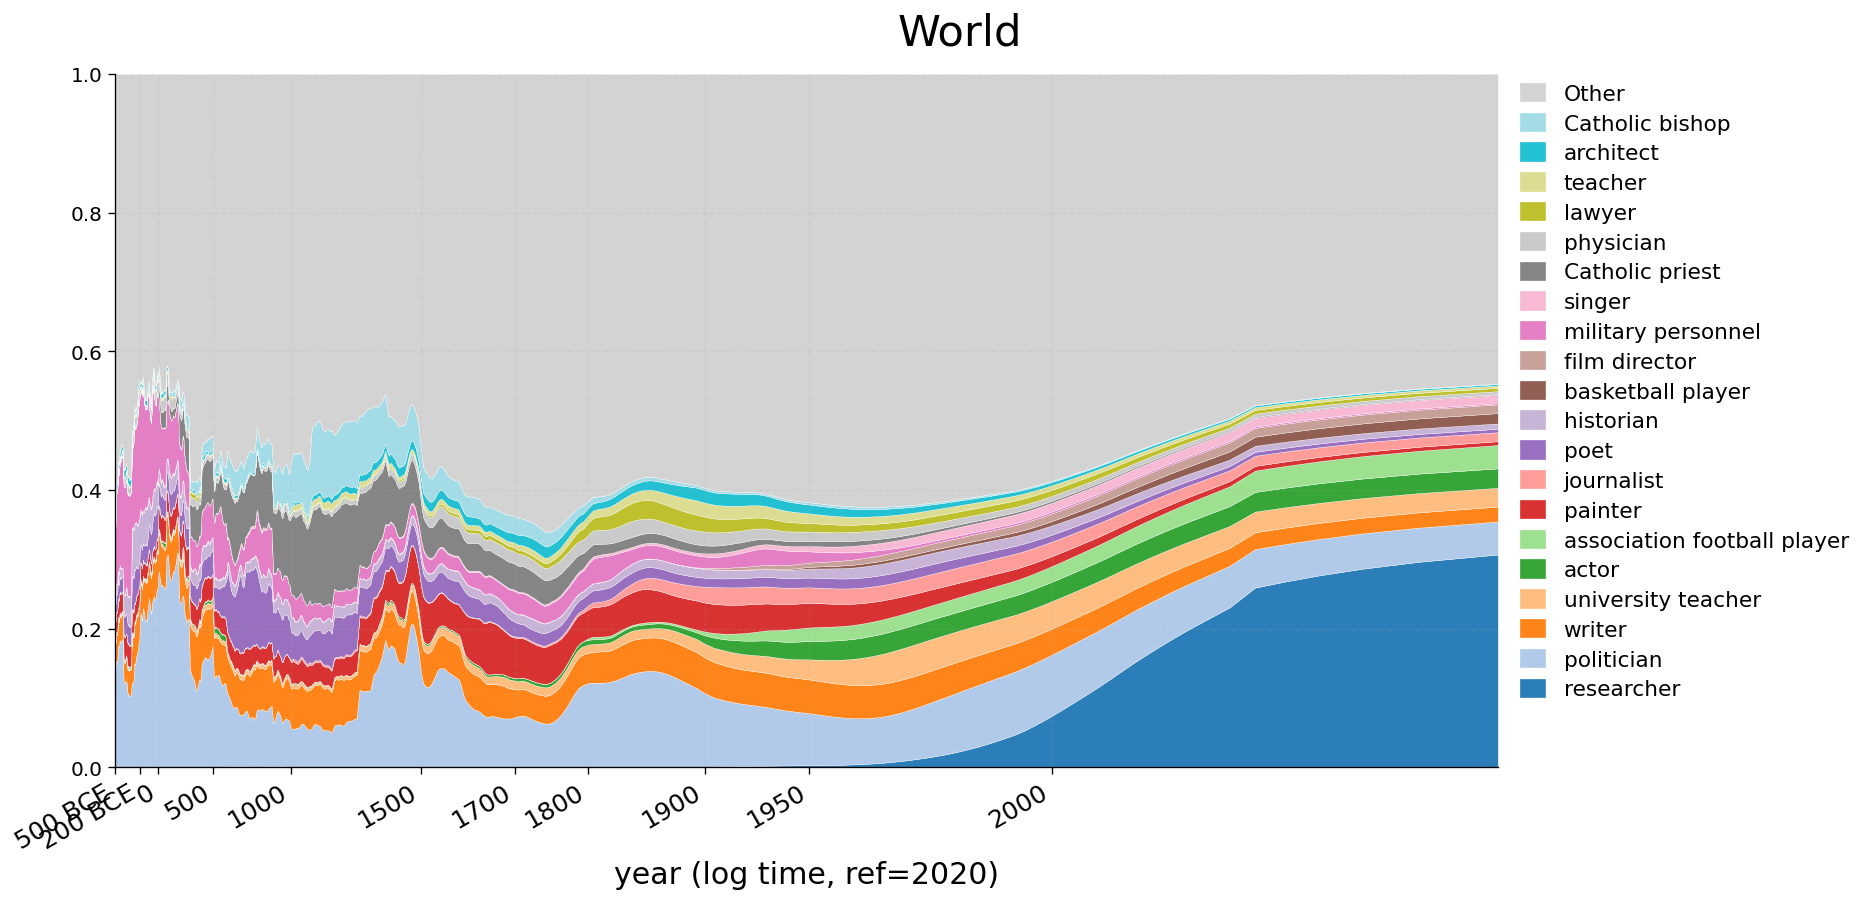

In [16]:
plot_share_area(
    world_years, world_order, world_counts, occupation_palette,
    scope_name='World',
    log_time=True, ref_year=2020,
)

## Fig 2 — Roman Empire

In [17]:
roman_years, roman_order, roman_counts = active_individuals_per_year(
    occupation_rows_roman, roman_occupations, ROMAN_RANGE
)

roman_year_share_preview = pl.DataFrame({
    'year': roman_years,
    **{occupation: roman_counts[occupation] for occupation in roman_order},
})
print('shape:', roman_year_share_preview.shape)
roman_year_share_preview.head()

shape: (500, 20)


year,politician,military personnel,writer,Catholic priest,presbyter,philosopher,poet,military officer,rabbi,historian,Catholic bishop,soldier,monk,priest,runner,mintmaster,orator,grammarian,Other
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
-100,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7
-99,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7
-98,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7
-97,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7
-96,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7


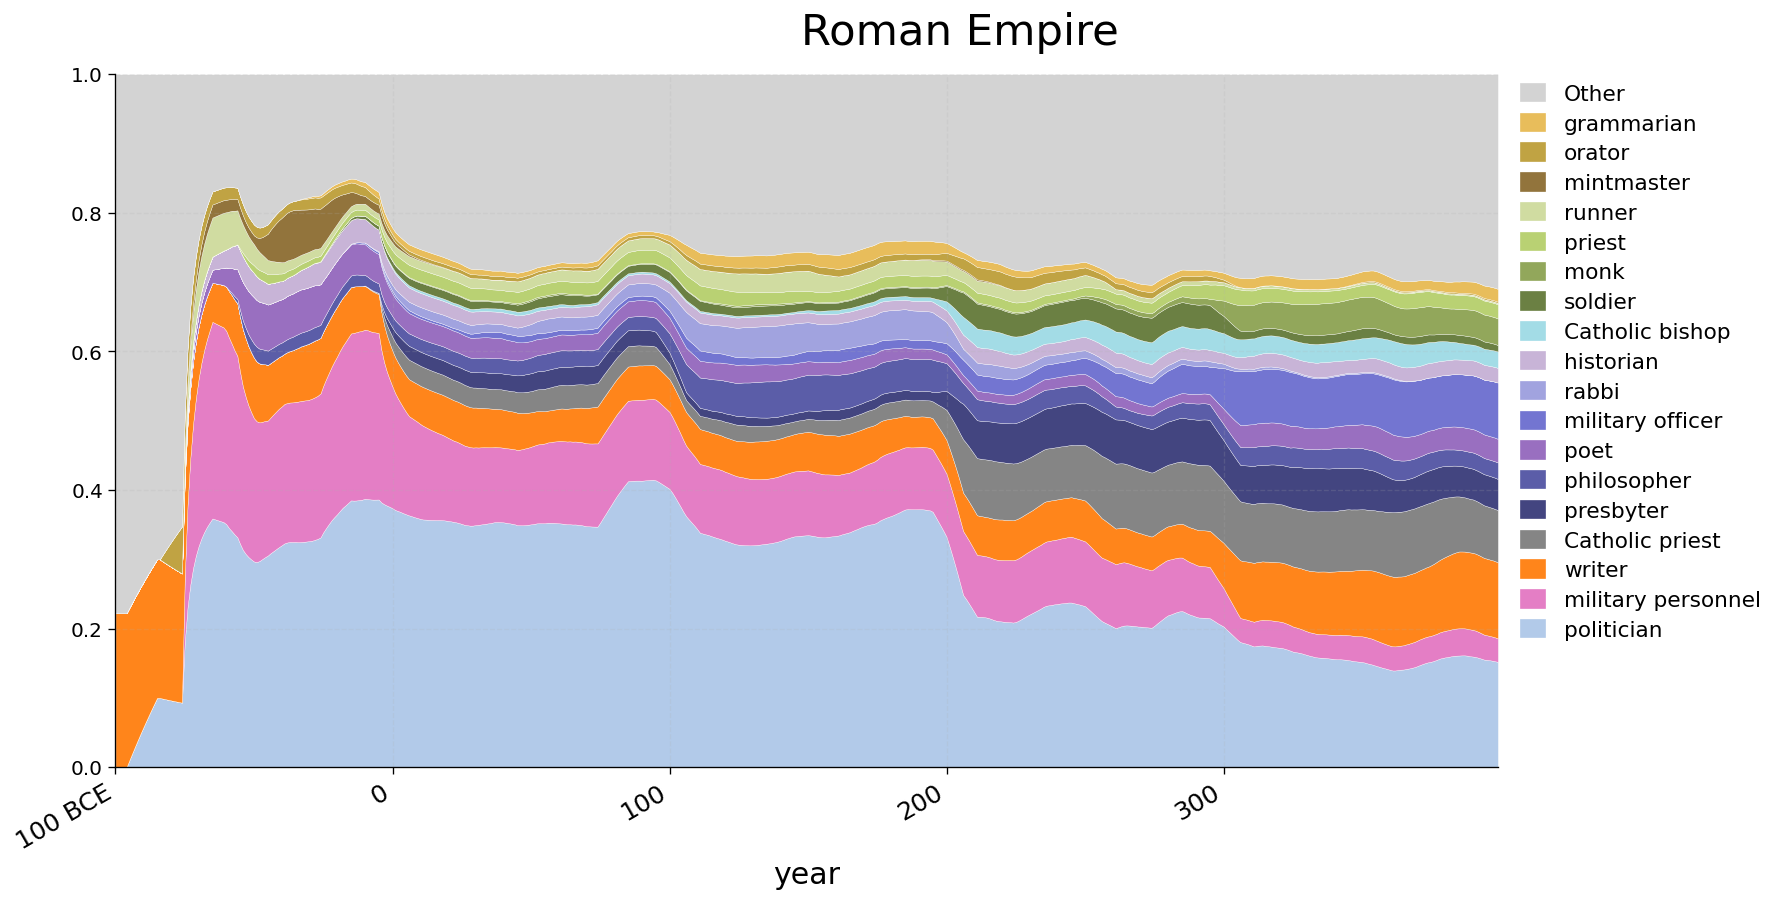

In [18]:
plot_share_area(
    roman_years, roman_order, roman_counts, occupation_palette,
    scope_name='Roman Empire',
    log_time=False,
    tick_years=list(range(ROMAN_RANGE[0], ROMAN_RANGE[1] + 1, 100)),
)

## Fig 3 — Tang Dynasty

In [19]:
tang_years, tang_order, tang_counts = active_individuals_per_year(
    occupation_rows_tang, tang_occupations, TANG_RANGE
)

tang_year_share_preview = pl.DataFrame({
    'year': tang_years,
    **{occupation: tang_counts[occupation] for occupation in tang_order},
})
print('shape:', tang_year_share_preview.shape)
tang_year_share_preview.head()

shape: (400, 17)


year,poet,politician,military personnel,writer,calligrapher,painter,Buddhist monk,military leader,official,historian,aristocrat,military officer,bureaucrat,monarch,ruler,Other
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
601,15,38,8,2,2,0,3,9,0,2,1,1,0,0,0,4
602,15,38,8,2,2,0,3,9,0,2,1,1,0,0,0,4
603,15,38,8,2,2,0,3,9,0,2,1,1,0,0,0,4
604,15,38,8,2,2,0,3,9,0,2,1,1,0,0,0,4


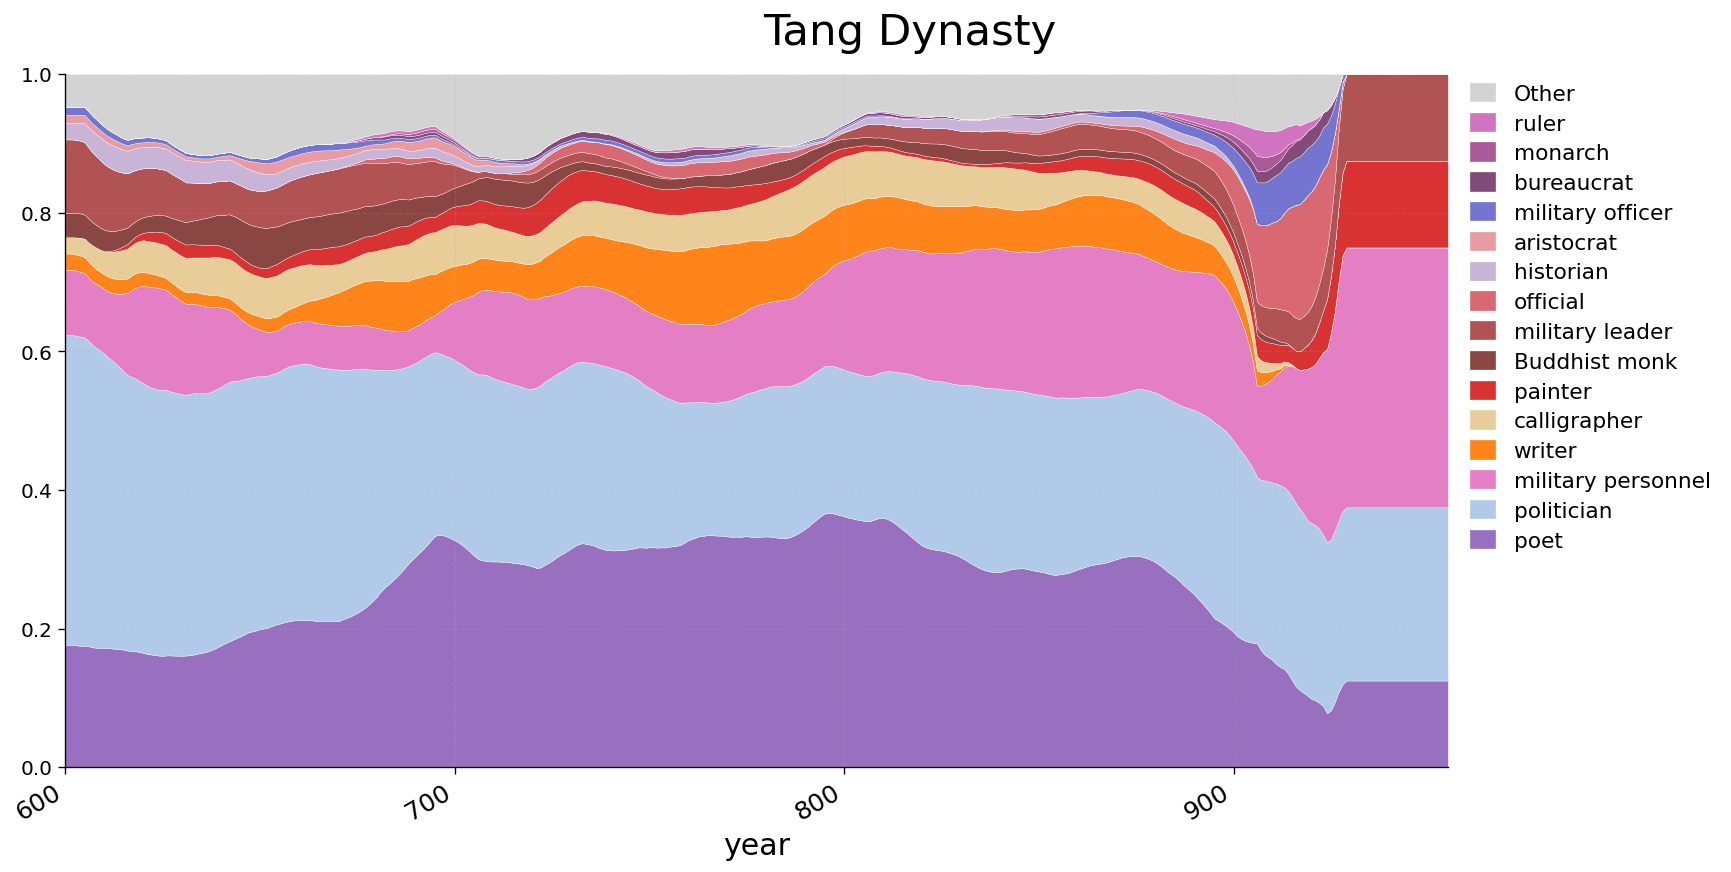

In [20]:
plot_share_area(
    tang_years, tang_order, tang_counts, occupation_palette,
    scope_name='Tang Dynasty',
    log_time=False,
    tick_years=list(range(TANG_RANGE[0], TANG_RANGE[1] + 1, 100)),
)

## Astronomers — raw cohort

In [21]:
astronomer_individuals = con.execute("""
    SELECT individuals.wikidata_id,
           individuals.occupations_en,
           floruit.floruit_period_start
    FROM   individuals
    JOIN   individuals_floruit_period AS floruit USING (wikidata_id)
    WHERE  individuals.occupations_en   LIKE '%astronomer%'
      AND  floruit.floruit_period_start IS NOT NULL
""").pl()

print('shape:', astronomer_individuals.shape)
astronomer_individuals.head()

shape: (11080, 3)


wikidata_id,occupations_en,floruit_period_start
str,str,i64
"""Q59673035""","""astronomer; researcher; physic…",2011
"""Q59673180""","""astronomer""",1982
"""Q59673296""","""astronomer""",2005
"""Q59673382""","""astronomer""",2012
"""Q59673436""","""astronomer; researcher""",2012


## Astronomers per period

In [22]:
def assign_astronomer_period(year):
    for label, (year_lo, year_hi) in ASTRONOMER_PERIODS.items():
        if year_lo <= year <= year_hi:
            return label
    return None

astronomers_with_period = (
    astronomer_individuals
    .with_columns(
        pl.col('floruit_period_start')
          .map_elements(assign_astronomer_period, return_dtype=pl.Utf8)
          .alias('period')
    )
    .filter(pl.col('period').is_not_null())
)

astronomers_per_period = (
    astronomers_with_period.group_by('period').len()
    .rename({'len': 'astronomer_count'})
    .sort('period')
)
print('shape:', astronomers_per_period.shape)
astronomers_per_period

shape: (3, 2)


period,astronomer_count
str,u32
"""1400 – 1650""",627
"""1750 – 1950""",3624
"""750 – 1250""",204


## Co-occupation counts per period

In [23]:
astronomer_variant_set = set(ASTRONOMER_VARIANTS)

occupation_counts_per_period = {label: Counter() for label in ASTRONOMER_PERIODS}
pair_counts_per_period       = {label: Counter() for label in ASTRONOMER_PERIODS}

for row in astronomers_with_period.iter_rows(named=True):
    period = row['period']
    occupations = [
        o.strip() for o in row['occupations_en'].split('; ')
        if o.strip() and o.strip().lower() not in astronomer_variant_set
    ]
    for occupation in occupations:
        occupation_counts_per_period[period][occupation] += 1
    for occ_a, occ_b in combinations(sorted(occupations), 2):
        pair_counts_per_period[period][(occ_a, occ_b)] += 1

for period in ASTRONOMER_PERIODS:
    print(f'{period:13s} → {len(occupation_counts_per_period[period]):4d} unique occupations,'
          f' {len(pair_counts_per_period[period]):5d} unique pairs')

750 – 1250    →  106 unique occupations,   902 unique pairs
1400 – 1650   →  203 unique occupations,  1683 unique pairs
1750 – 1950   →  441 unique occupations,  3106 unique pairs


## Top co-occupations per period

In [24]:
top_cooccupations_per_period = pl.concat([
    pl.DataFrame(
        occupation_counts_per_period[period].most_common(NETWORK_NODE_COUNT),
        schema=['occupation', 'individual_count'],
        orient='row',
    ).with_columns(pl.lit(period).alias('period'))
     .select(['period', 'occupation', 'individual_count'])
    for period in ASTRONOMER_PERIODS
])

print('shape:', top_cooccupations_per_period.shape)
top_cooccupations_per_period

shape: (45, 3)


period,occupation,individual_count
str,str,i64
"""750 – 1250""","""astronomer""",204
"""750 – 1250""","""mathematician""",100
"""750 – 1250""","""astrologer""",86
"""750 – 1250""","""philosopher""",41
"""750 – 1250""","""writer""",39
…,…,…
"""1750 – 1950""","""surveyor""",71
"""1750 – 1950""","""philosopher""",53
"""1750 – 1950""","""photographer""",51


## Fig 4 — Astronomer co-occupation networks

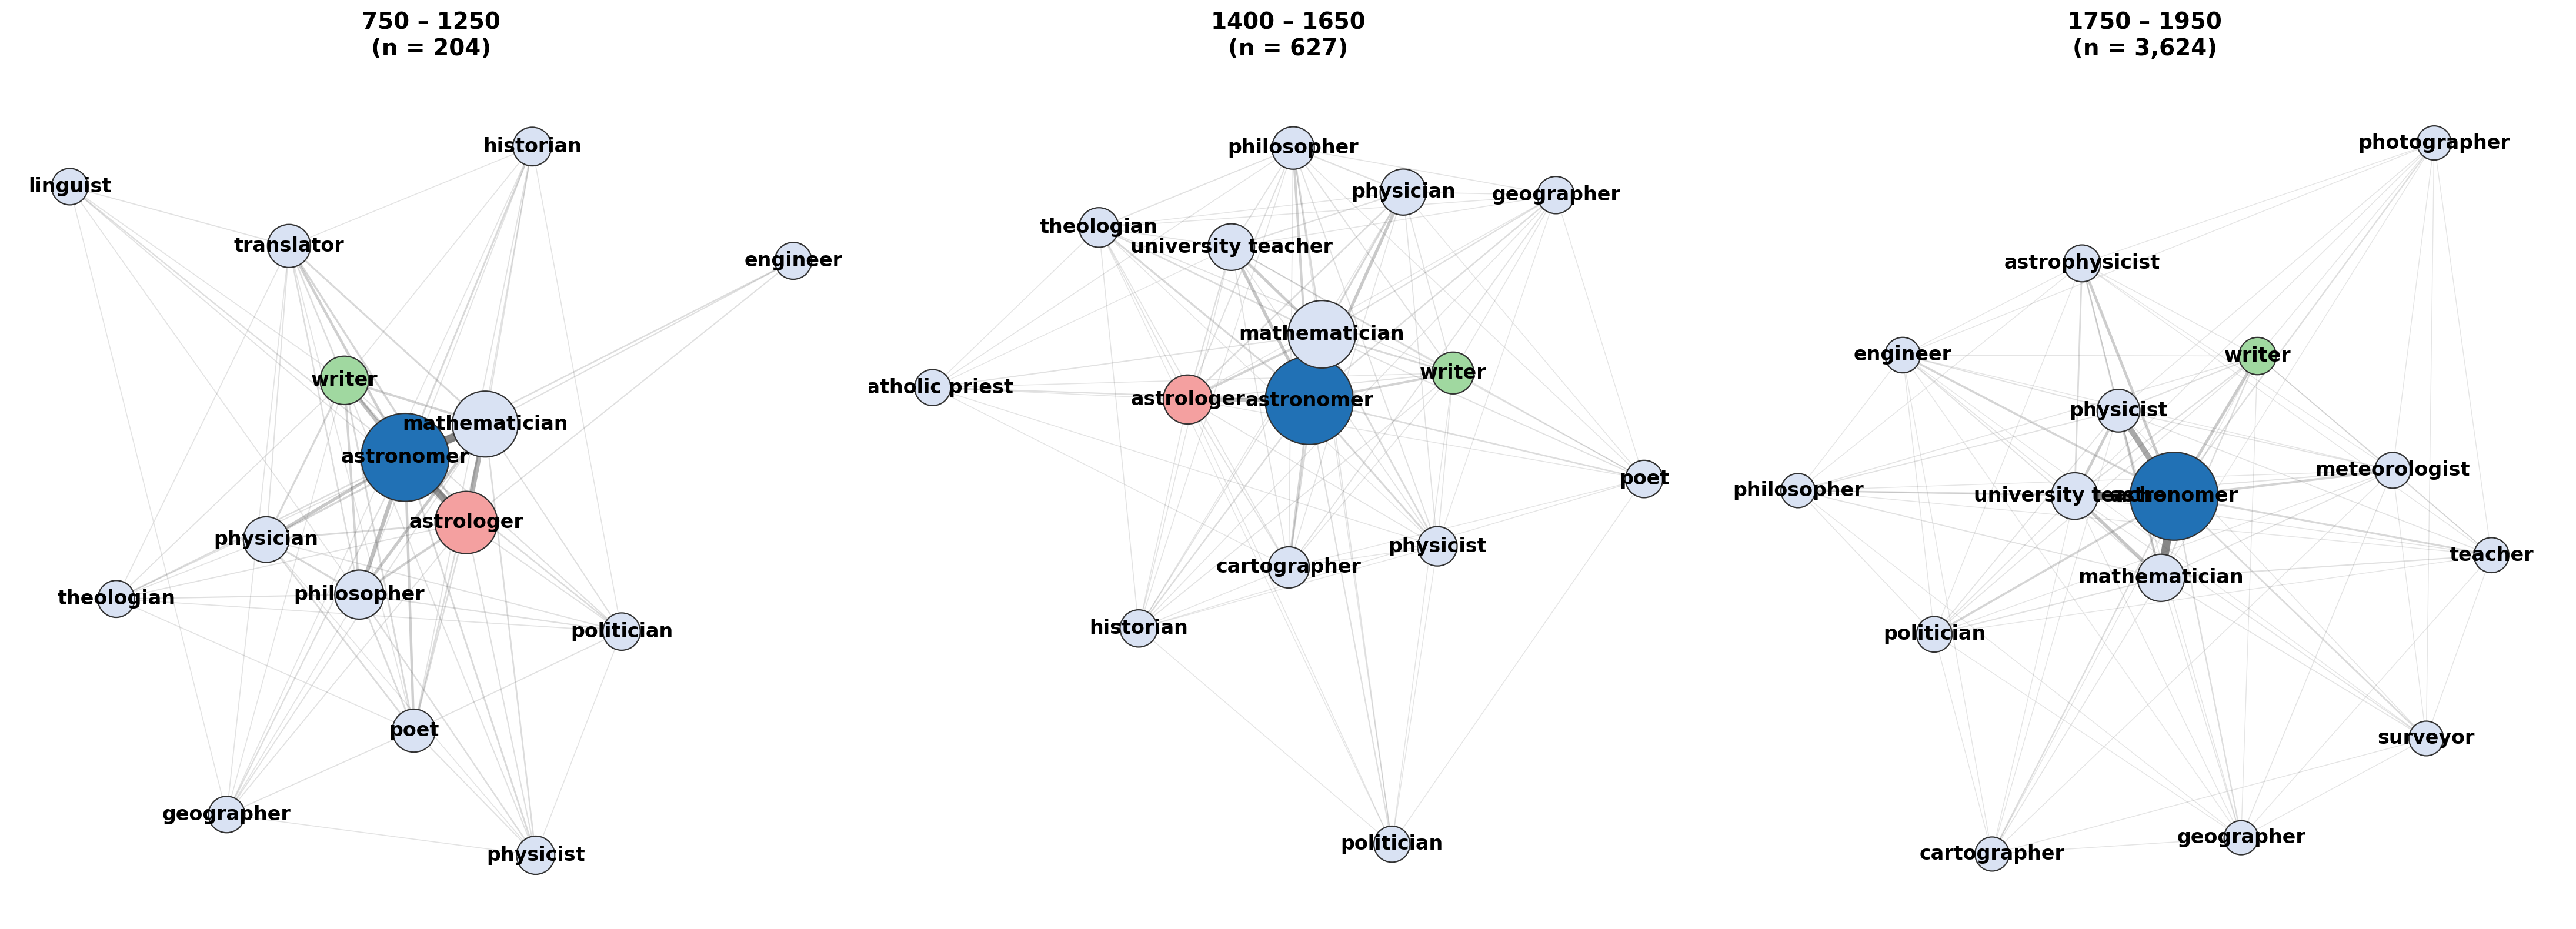

In [25]:
def network_node_color(occupation):
    if occupation == 'astronomer':
        return COLORS['astronomer']
    if occupation == 'astrologer':
        return COLORS['astrologer']
    if occupation == 'writer':
        return COLORS['writer']
    return COLORS['other_node']

fig, axes = plt.subplots(1, 3, figsize=(22, 8), dpi=200)
for ax, period_label in zip(axes, ASTRONOMER_PERIODS):
    top_occupations = [occ for occ, _ in occupation_counts_per_period[period_label].most_common(NETWORK_NODE_COUNT)]
    if 'astronomer' not in top_occupations:
        top_occupations = ['astronomer'] + top_occupations[:NETWORK_NODE_COUNT - 1]
    top_set = set(top_occupations)

    graph = nx.Graph()
    for occupation in top_occupations:
        graph.add_node(occupation, count=occupation_counts_per_period[period_label][occupation])
    for (occ_a, occ_b), pair_count in pair_counts_per_period[period_label].items():
        if occ_a in top_set and occ_b in top_set and pair_count >= NETWORK_MIN_EDGE_COUNT:
            graph.add_edge(occ_a, occ_b, weight=pair_count)

    layout = nx.spring_layout(graph, k=2.0, iterations=150, seed=SEED, weight='weight')

    node_individual_counts = [graph.nodes[n]['count'] for n in graph.nodes()]
    max_node_count = max(node_individual_counts)
    node_sizes  = [400 + 2500 * (c / max_node_count) for c in node_individual_counts]
    node_colors = [network_node_color(n) for n in graph.nodes()]

    if graph.edges():
        edge_weights    = [graph.edges[e]['weight'] for e in graph.edges()]
        max_edge_weight = max(edge_weights)
        edge_widths     = [0.5 + 4.5 * (w / max_edge_weight) for w in edge_weights]
        edge_alphas     = [0.15 + 0.55 * (w / max_edge_weight) for w in edge_weights]
        for (u, v), width, alpha in zip(graph.edges(), edge_widths, edge_alphas):
            nx.draw_networkx_edges(graph, layout, edgelist=[(u, v)], ax=ax,
                                   width=width, edge_color=COLORS['edge'], alpha=alpha)

    nx.draw_networkx_nodes(graph, layout, ax=ax, node_size=node_sizes,
                           node_color=node_colors, edgecolors='#333333', linewidths=0.8)
    nx.draw_networkx_labels(graph, layout, labels={n: n for n in graph.nodes()},
                            ax=ax, font_size=12, font_color='black', font_weight='bold')

    cohort_size = (
        astronomers_per_period
        .filter(pl.col('period') == period_label)
        .select('astronomer_count').item()
    )
    ax.set_title(f'{period_label}\n(n = {cohort_size:,})', fontsize=14, fontweight='bold', pad=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Clean up

In [26]:
con.close()